In [1]:
!pip install mysql-connector-python

In [2]:
import mysql.connector

In [3]:
conn = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",       # replace with your MySQL username
    password="1234",   # replace with your MySQL password
    database="sales_data_db"    # replace with your database name
)

cursor = conn.cursor()

In [4]:
# Create the sales table (if it doesn't already exist)
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INT PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
    )
''')

In [5]:
# Insert sample data
sample_data = [

('101','Laptop', '3', '800'),
('104','Mouse', '10', '20'),
('107','Keyboard', '5', '50'),
('607','Monitor', '4', '200')
]
cursor.execute("delete from sales")
conn.commit()
cursor.executemany("INSERT INTO sales (id, product, quantity, price) VALUES (%s, %s, %s, %s)", sample_data)

#conn.commit()
#cursor.close()
#conn.close()


In [6]:
#sql query
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product;
"""


In [13]:
#import the pandas for sql query
import pandas as pd

df = pd.read_sql_query(query, conn)  # conn is your SQL connection
print(df)


    product  total_qty  revenue
0    Laptop        3.0   2400.0
1     Mouse       10.0    200.0
2  Keyboard        5.0    250.0
3   Monitor        4.0    800.0


C:\Users\priya\AppData\Local\Temp\ipykernel_11944\1108991367.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)  # conn is your SQLite connection


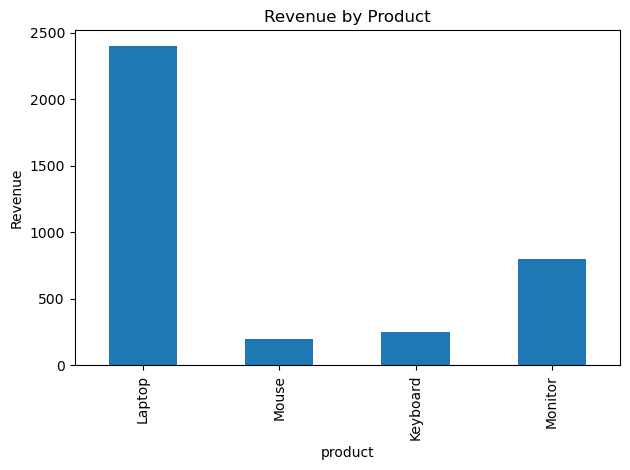

In [15]:
#create an barplot 
import matplotlib.pyplot as plt

df.plot(kind='bar', x='product', y='revenue', legend=False, title='Revenue by Product')
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Optional: saves the chart
plt.show()
